In [260]:

import pandas as pd
import numpy as np


In [261]:
data = []

In [262]:
for age in range(0,101):
 if age <= 20:
  sport = "Cricket"
 elif age <= 40:
   sport = "Football"
 elif age <=60:
   sport = "Hockey"
 elif age<=80:
  sport = "Dogball"
 else:
  sport = "vollyball"

 data.append([age,sport])


In [263]:
df = pd.DataFrame(data,columns=["Age","Sport"])

In [264]:
print(df)


     Age      Sport
0      0    Cricket
1      1    Cricket
2      2    Cricket
3      3    Cricket
4      4    Cricket
..   ...        ...
96    96  vollyball
97    97  vollyball
98    98  vollyball
99    99  vollyball
100  100  vollyball

[101 rows x 2 columns]


In [265]:
df.to_csv("sports_dataset.csv")

step 2: Data Argumentation


In [266]:
df = pd.read_csv("sports_dataset.csv")

In [267]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  101 non-null    int64 
 1   Age         101 non-null    int64 
 2   Sport       101 non-null    object
dtypes: int64(2), object(1)
memory usage: 2.5+ KB


In [268]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sport,0


In [269]:
df.describe()

,Unnamed: 0,Age
count,101.000000,101.000000
mean,50.000000,50.000000
std,29.300171,29.300171
min,0.000000,0.000000
25%,25.000000,25.000000
50%,50.000000,50.000000
75%,75.000000,75.000000
max,100.000000,100.000000


In [270]:
df.head(20)

,Unnamed: 0,Age,Sport
0,0,0,Cricket
1,1,1,Cricket
2,2,2,Cricket
3,3,3,Cricket
4,4,4,Cricket
5,5,5,Cricket
6,6,6,Cricket
7,7,7,Cricket
8,8,8,Cricket
9,9,9,Cricket


In [271]:
len(df)

101

In [272]:
#remove duplicate values
df = df.drop_duplicates()

In [273]:
#remove rows with mising values
df = df.dropna()

In [274]:
#remove invalid age
df =df[(df["Age"]>=1) & (df["Age"]<=100)]

In [275]:
df.shape

(100, 3)

In [276]:
df = df.sort_values("Age").reset_index(drop=True)

In [277]:
display(df)

,Unnamed: 0,Age,Sport
0,1,1,Cricket
1,2,2,Cricket
2,3,3,Cricket
3,4,4,Cricket
4,5,5,Cricket
...,...,...,...
95,96,96,vollyball
96,97,97,vollyball
97,98,98,vollyball
98,99,99,vollyball


In [278]:
df.to_csv("sports_dataset_cleared.csv",index=False)

In [279]:
df = pd.read_csv("sports_dataset_cleared.csv")

In [280]:
df.shape


(100, 3)

create ML DecisionTree based model

In [281]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [282]:
#load dataset
df = pd.read_csv("sports_dataset_cleared.csv")

In [283]:
# feature and target
x = df[["Age"]]
y = df[["Sport"]]


In [284]:
#split_state
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [285]:
#Train DecisionTree
model = DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [286]:
#predication
y_pred = model.predict(x_test)

In [287]:
#accuracy
accuracy = accuracy_score(y_test,y_pred)
print("Accuracy Score:",accuracy)




Accuracy Score: 0.95


In [294]:
age =20
prediction = model.predict([[age]])
print(prediction)

['Cricket']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [297]:
test_ages = [[15],[28],[102],[-1]]

prediction = model.predict(test_ages)
print(prediction)

['Cricket' 'Football' 'vollyball' 'Cricket']


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


Visualize Model


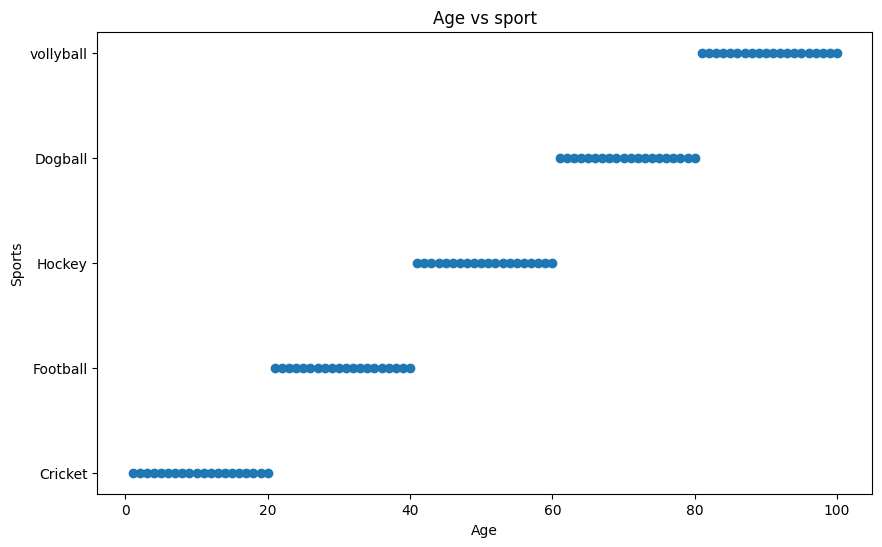

In [298]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(df["Age"],df["Sport"])
plt.xlabel("Age")
plt.ylabel("Sports")
plt.title("Age vs sport")
plt.show()

In [299]:
import pickle

#save model
with open("sports_model.pkl","wb") as file:
  pickle.dump(model,file)
  print("Model saved successfully as a sports_model.pkl")

Model saved successfully as a sports_model.pkl
